In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap
import numpy as np

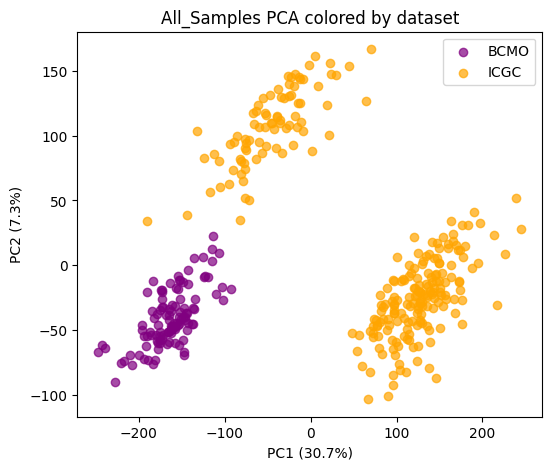

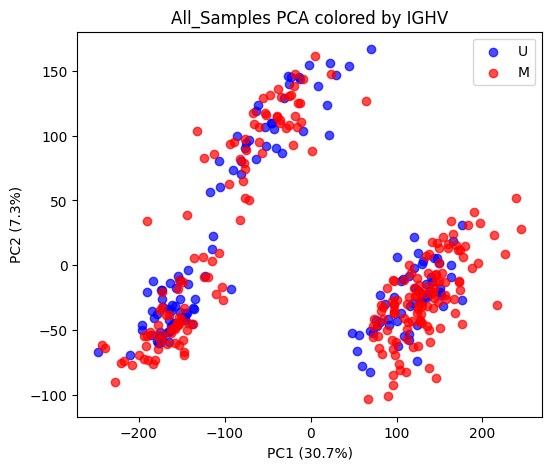

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ Load the count matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)   # genes as rows, samples as columns?
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/count_matrix.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
# For BCMO
bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
# Log2 transform BCMO counts
bcmo_counts = (bcmo_counts + 1).apply(np.log2)

# For ICGC
icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ Define a function to perform PCA and plot
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    explained_var = pca.explained_variance_ratio_ * 100  # percentage

    # Define custom colors
    if color_by == "dataset":
        color_map = {"BCMO": "purple", "ICGC": "orange"}
    elif color_by == "IGHV":
        color_map = {"U": "blue", "M": "red"}
    else:
        color_map = {status: None for status in metadata[color_by].unique()}
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(
            pca_res[idx,0], pca_res[idx,1],
            label=status,
            alpha=0.7,
            color=color_map.get(status, None)
        )
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.legend()

    # Save figure (300 dpi PNG)
    plt.savefig(f"../../figures/PCA_{title_prefix}_{color_by}.png", dpi=300, bbox_inches="tight")
    plt.show()

# 5️⃣ Apply by dataset
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All_Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All_Samples")


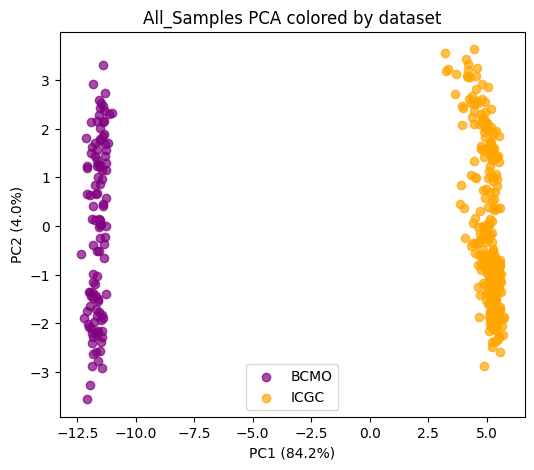

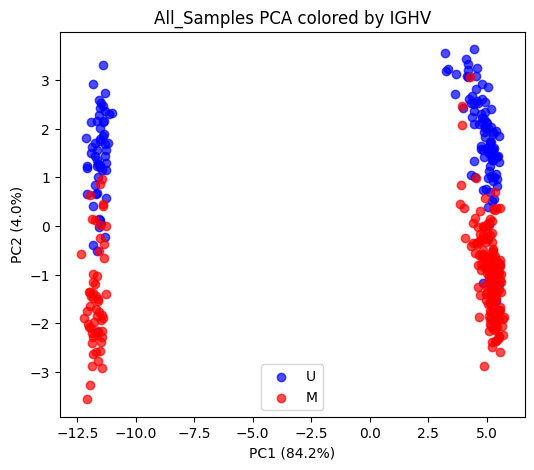

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ Load the activity matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/activity_matrix_pvalfilt.csv", index_col=0)   # genes as rows, samples as columns
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/activity_matrix_pvalfilt.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
# For BCMO
missing_bcmo = set(bcmo_meta["Sample_ID"]) - set(bcmo_counts.columns)
if missing_bcmo:
    print("⚠️ BCMO metadata samples missing in count matrix:", missing_bcmo)

bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
bcmo_counts = (bcmo_counts + 1).apply(np.log2)  # log2 transform

# For ICGC
missing_icgc = set(icgc_meta["Samples"]) - set(icgc_counts.columns)
if missing_icgc:
    print("⚠️ ICGC metadata samples missing in count matrix:", missing_icgc)

icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ PCA plotting function
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # Drop NaN values (safe for PCA)
    data = data.dropna(axis=0, how="any")
    
    # Keep aligned metadata
    metadata = metadata.loc[metadata["Sample"].isin(data.index)]
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    explained_var = pca.explained_variance_ratio_ * 100  # percentage

    # Define custom colors
    if color_by == "dataset":
        color_map = {"BCMO": "purple", "ICGC": "orange"}
    elif color_by == "IGHV":
        color_map = {"U": "blue", "M": "red"}
    else:
        color_map = {status: None for status in metadata[color_by].unique()}
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(
            pca_res[idx,0], pca_res[idx,1],
            label=status,
            alpha=0.7,
            color=color_map.get(status, None)
        )
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.legend()

    # Save figure (300 dpi PNG)
    plt.savefig(f"../../figures/PCA_{title_prefix}_{color_by}.png", dpi=300, bbox_inches="tight")
    plt.show()

# 5️⃣ Combine datasets
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# Handle NaNs introduced by misalignment
if combined_counts.isna().any().any():
    print("⚠️ NaN values detected in combined counts — dropping genes/samples with NaN")
    combined_counts = combined_counts.dropna(axis=0, how="any")
    combined_counts = combined_counts.dropna(axis=1, how="any")

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All_Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All_Samples")
